# Analyse-Notebook — M3 bis M6

Dieses Notebook implementiert alle analytischen Methoden des Projekts:
- **M3** — NLP: Sentiment-Analyse auf Reviews (Top vs. Bottom Läden)
- **M4** — Logistische Regression: Was macht einen erfolgreichen Dönerläden aus?
- **M5** — Moran's I: Räumliche Autokorrelation (Global + LISA)
- **M6** — k-Means: PLR-Typisierung (Kiez-Cluster)

**Voraussetzung:** `berlin_masterdata.db` muss bereits vorhanden sein (nb_03 ausführen).

**Outputs:** Visualisierungen + zwei neue Spalten in `berlin_masterdata.db`:
- `lisa_cluster` (M5): HH / LL / HL / LH / ns (not significant)
- `kiez_typ` (M6): Cluster-Label (z.B. "Studentenviertel", "Bürokiez")

In [35]:
# Einmalig ausführen falls Pakete fehlen
# !pip install vaderSentiment libpysal esda
import subprocess, sys
for pkg in ['vaderSentiment', 'libpysal', 'esda']:
    try:
        __import__(pkg.replace('-','_').split('.')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
print("Pakete OK")

Pakete OK


In [36]:
import json, sqlite3, math, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')

# Pfade
DB_PATH      = Path('berlin_masterdata.db')
DOENER_JSON  = Path('dataset_berlin_doener.json')
LOR_GEOJSON  = Path('lor_planungsraeume_2021.geojson')

# Haupt-Datensatz laden
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql('SELECT * FROM planungsraeume', conn)
conn.close()

print(f"Datensatz geladen: {len(df)} PLR, {len(df.columns)} Spalten")
print(df[['plr_id','plr_name','bezirk','doener_count','transit_count']].head(3))

Datensatz geladen: 542 PLR, 35 Spalten
     plr_id                  plr_name                    bezirk  doener_count  \
0  11501341            Karlshorst Süd               Lichtenberg             2   
1  07601340  Tirschenreuther Ring Ost     Tempelhof-Schoeneberg             1   
2  02500831               Wismarplatz  Friedrichshain-Kreuzberg             2   

   transit_count  
0             25  
1              4  
2              7  


## M3 — NLP: Sentiment-Analyse auf Reviews

**Ziel:** Was unterscheidet die Sprache in Reviews von erfolgreichen vs. schlechten Dönerläden?

**Methodik:**
- Top 10% Läden: rating ≥ 4.3 UND userRatingCount ≥ 50 (ca. 135 Läden)
- Bottom 10% Läden: rating ≤ 3.5 UND userRatingCount ≥ 20 (ca. 135 Läden)
- Sentiment: VADER (regelbasiert, kein Training, funktioniert für kurze Texte)
- Theme-Extraktion: Keyword-Listen für 4 Themen (Preis, Qualität, Service, Hygiene)
- Output: Radar-Chart Top vs. Bottom + Häufigste Begriffe

**Limitierung:** VADER ist für Englisch optimiert. Deutsche Reviews haben tendenziell
niedrigere Compound-Scores. Die relativen Unterschiede zwischen Top/Bottom sind aber aussagekräftig.

In [37]:
with open(DOENER_JSON, encoding='utf-8') as f:
    raw = json.load(f)

# Datei hat Wrapper-Struktur: {'metadata': ..., 'summary': ..., 'places': [...]}
shops = raw['places'] if isinstance(raw, dict) and 'places' in raw else raw

# erfolg_flag: rating >= 4.3 AND userRatingCount >= 200
for s in shops:
    s['erfolg_flag'] = int(
        (s.get('rating') or 0) >= 4.3 and
        (s.get('userRatingCount') or 0) >= 200
    )

# Top 10%: hohe Bewertung + genug Reviews
top_shops = [s for s in shops if (s.get('rating') or 0) >= 4.3 and (s.get('userRatingCount') or 0) >= 50]
bot_shops = [s for s in shops if (s.get('rating') or 0) <= 3.5 and (s.get('userRatingCount') or 0) >= 20]

print(f'Top-Laeden (>=4.3 Sterne, >=50 Reviews): {len(top_shops)}')
print(f'Bottom-Laeden (<=3.5 Sterne, >=20 Reviews): {len(bot_shops)}')
print(f'erfolg_flag=1: {sum(s["erfolg_flag"] for s in shops)} Laeden')


Top-Laeden (>=4.3 Sterne, >=50 Reviews): 794
Bottom-Laeden (<=3.5 Sterne, >=20 Reviews): 64
erfolg_flag=1: 531 Laeden


In [38]:
def extract_reviews(shop_list, lang_filter=None):
    """Extrahiert alle Review-Texte aus einer Shop-Liste.
    Reviews sind bereits Dicts (kein json.loads noetig).
    Sprachcode liegt in review['text']['languageCode'].
    """
    texts = []
    for s in shop_list:
        reviews = s.get('reviews') or []
        for r in reviews:
            if not isinstance(r, dict):
                continue
            text_obj = r.get('text', {})
            text = text_obj.get('text', '') if isinstance(text_obj, dict) else str(text_obj)
            lang = text_obj.get('languageCode', '') if isinstance(text_obj, dict) else ''
            if text and len(text) > 10:
                if lang_filter is None or lang == lang_filter:
                    texts.append(text)
    return texts

reviews_top    = extract_reviews(top_shops)
reviews_bot    = extract_reviews(bot_shops)
reviews_top_de = extract_reviews(top_shops, lang_filter='de')
reviews_bot_de = extract_reviews(bot_shops, lang_filter='de')

print(f'Top-Reviews gesamt:   {len(reviews_top)} (davon deutsch: {len(reviews_top_de)})')
print(f'Bottom-Reviews gesamt: {len(reviews_bot)} (davon deutsch: {len(reviews_bot_de)})')


Top-Reviews gesamt:   3970 (davon deutsch: 3970)
Bottom-Reviews gesamt: 319 (davon deutsch: 319)


In [39]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def batch_sentiment(texts):
    scores = [analyzer.polarity_scores(t)['compound'] for t in texts]
    return {
        'mean':   round(np.mean(scores), 3),
        'median': round(np.median(scores), 3),
        'pos':    round(np.mean([s for s in scores if s > 0.05]), 3) if any(s > 0.05 for s in scores) else 0,
        'neg':    round(np.mean([s for s in scores if s < -0.05]), 3) if any(s < -0.05 for s in scores) else 0,
        'pct_positive': round(sum(1 for s in scores if s > 0.05) / len(scores) * 100, 1),
        'pct_negative': round(sum(1 for s in scores if s < -0.05) / len(scores) * 100, 1),
    }

sent_top = batch_sentiment(reviews_top)
sent_bot = batch_sentiment(reviews_bot)

print("Sentiment Top-Läden:", sent_top)
print("Sentiment Bottom-Läden:", sent_bot)

Sentiment Top-Läden: {'mean': np.float64(-0.379), 'median': np.float64(-0.599), 'pos': np.float64(0.576), 'neg': np.float64(-0.77), 'pct_positive': 16.5, 'pct_negative': 61.5}
Sentiment Bottom-Läden: {'mean': np.float64(-0.543), 'median': np.float64(-0.688), 'pos': np.float64(0.547), 'neg': np.float64(-0.783), 'pct_positive': 5.6, 'pct_negative': 73.4}


In [40]:
THEMES = {
    'Preis':     ['preis', 'günstig', 'teuer', 'billig', 'wert', 'kosten', 'euro', 'lohnt', 'überpreis', 'fair'],
    'Qualität':  ['frisch', 'lecker', 'fleisch', 'soße', 'sauce', 'geschmack', 'qualität', 'trocken', 'saftig', 'gewürz'],
    'Service':   ['freundlich', 'schnell', 'langsam', 'service', 'warten', 'personal', 'mitarbeiter', 'unhöflich', 'nett'],
    'Hygiene':   ['sauber', 'dreckig', 'hygiene', 'schmutzig', 'appetitlich', 'küche', 'tisch', 'boden'],
}

def theme_score(texts, theme_keywords):
    """Anteil der Texte die mind. 1 Keyword des Themas enthalten (normiert 0-1)."""
    hits = sum(1 for t in texts if any(k in t.lower() for k in theme_keywords))
    return round(hits / len(texts), 3) if texts else 0

themes_top = {t: theme_score(reviews_top_de or reviews_top, kws) for t, kws in THEMES.items()}
themes_bot = {t: theme_score(reviews_bot_de or reviews_bot, kws) for t, kws in THEMES.items()}

print("Theme-Scores Top:", themes_top)
print("Theme-Scores Bottom:", themes_bot)

Theme-Scores Top: {'Preis': 0.366, 'Qualität': 0.766, 'Service': 0.571, 'Hygiene': 0.185}
Theme-Scores Bottom: {'Preis': 0.326, 'Qualität': 0.649, 'Service': 0.473, 'Hygiene': 0.119}


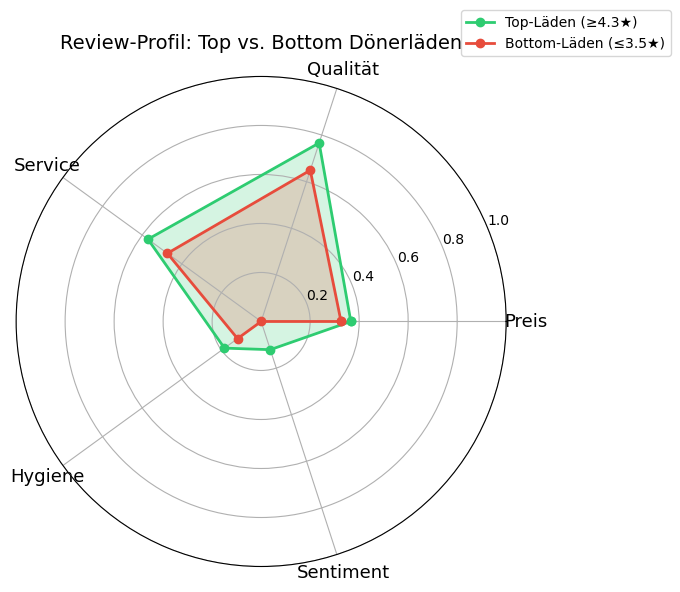

Gespeichert: nlp_radar_top_vs_bottom.png


In [41]:
labels = list(THEMES.keys()) + ['Sentiment']
top_vals = [themes_top[t] for t in THEMES] + [max(0, sent_top['mean'] + 0.5)]  # normalize to 0-1
bot_vals = [themes_bot[t] for t in THEMES] + [max(0, sent_bot['mean'] + 0.5)]

N = len(labels)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]
top_vals += top_vals[:1]
bot_vals += bot_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, top_vals, 'o-', linewidth=2, color='#2ecc71', label='Top-Läden (≥4.3★)')
ax.fill(angles, top_vals, alpha=0.2, color='#2ecc71')
ax.plot(angles, bot_vals, 'o-', linewidth=2, color='#e74c3c', label='Bottom-Läden (≤3.5★)')
ax.fill(angles, bot_vals, alpha=0.2, color='#e74c3c')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylim(0, 1)
ax.set_title('Review-Profil: Top vs. Bottom Dönerläden', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.savefig('nlp_radar_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: nlp_radar_top_vs_bottom.png")

## M4 — Logistische Regression: Erfolgs-Prognose

**Zielvariable:** `erfolg_flag` pro Laden (rating ≥ 4.3 UND userRatingCount ≥ 200)

**Prädiktoren:** PLR-Standortfaktoren (Laden wird seinem PLR zugeordnet über die
bereits berechneten PLR-Aggregat-Daten in berlin_masterdata.db)

**Methodik:**
- 80/20 Train/Test Split (stratifiziert nach erfolg_flag)
- StandardScaler Normierung
- LogisticRegression mit L2-Regularisierung (C=1.0)
- Evaluation: Accuracy, AUC-ROC, Confusion Matrix
- Visualisierung: Coefficient Plot (Forest Plot)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Abgeleitete Spalten on-the-fly berechnen falls in DB noch nicht vorhanden
# (Fallback falls nb_03 noch nicht neu ausgefuehrt wurde)
if 'wettbewerb_index' not in df.columns or df['wettbewerb_index'].isna().all():
    df['wettbewerb_index'] = (
        (df['doener_count'] + df['fastfood_count'])
        / df['einwohner_gesamt'].replace(0, np.nan) * 1000
    )
    print('wettbewerb_index berechnet (Fallback)')

if 'gastro_fluktuation' not in df.columns or df['gastro_fluktuation'].isna().all():
    df['gastro_fluktuation'] = (
        df['gastro_neu'] / df['gastro_gesamt'].replace(0, np.nan)
    )
    print('gastro_fluktuation berechnet (Fallback)')

# anteil_18_35 berechnen
df['anteil_18_35_calc'] = (
    df['einwohner_18_35'] / df['einwohner_gesamt'].replace(0, np.nan)
)

FEATURE_COLS = [
    'einwohner_dichte', 'anteil_18_35_calc',
    'transit_count', 'nightlife_count', 'office_count',
    'university_count', 'school_count',
    'medianeinkommen_eur', 'mss_status_index',
    'wettbewerb_index', 'gastro_fluktuation',
]

# NaN mit Median auffuellen (Median selbst darf nicht NaN sein)
df_feat = df.set_index('plr_id')[FEATURE_COLS].copy()
for col in FEATURE_COLS:
    median_val = df_feat[col].median()
    if pd.isna(median_val):
        median_val = 0.0  # letzter Fallback
    df_feat[col] = df_feat[col].fillna(median_val)

# Shop-Datensatz: jedem Laden die Standortfaktoren seines PLR zuweisen
shop_rows = []
for s in shops:
    loc = s.get('location', {})
    lat = loc.get('latitude') if isinstance(loc, dict) else None
    lng = loc.get('longitude') if isinstance(loc, dict) else None
    if lat is None or lng is None:
        continue
    dists = (df['centroid_lat'] - lat)**2 + (df['centroid_lng'] - lng)**2
    plr_id = df.loc[dists.idxmin(), 'plr_id']
    if plr_id not in df_feat.index:
        continue
    row = {'erfolg_flag': s['erfolg_flag']}
    row.update(df_feat.loc[plr_id].to_dict())
    shop_rows.append(row)

df_shops = pd.DataFrame(shop_rows).dropna(subset=['erfolg_flag'])
print(f'Shop-Datensatz: {len(df_shops)} Laeden')
print(f'NaN in Features: {df_shops[FEATURE_COLS].isna().sum().sum()} (sollte 0 sein)')
print(f'erfolg_flag: {df_shops["erfolg_flag"].value_counts().to_dict()}')


Shop-Datensatz: 1346 Laeden
NaN in Features: 0 (sollte 0 sein)
erfolg_flag: {0: 815, 1: 531}


In [43]:
feature_names = [c for c in df_shops.columns if c != 'erfolg_flag']
X = df_shops[feature_names].values
y = df_shops['erfolg_flag'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

print("=== Logistische Regression — Ergebnisse ===")
print(classification_report(y_test, y_pred, target_names=['kein Erfolg', 'Erfolg']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

=== Logistische Regression — Ergebnisse ===
              precision    recall  f1-score   support

 kein Erfolg       0.63      0.88      0.74       163
      Erfolg       0.56      0.22      0.32       107

    accuracy                           0.62       270
   macro avg       0.60      0.55      0.53       270
weighted avg       0.60      0.62      0.57       270

AUC-ROC: 0.613


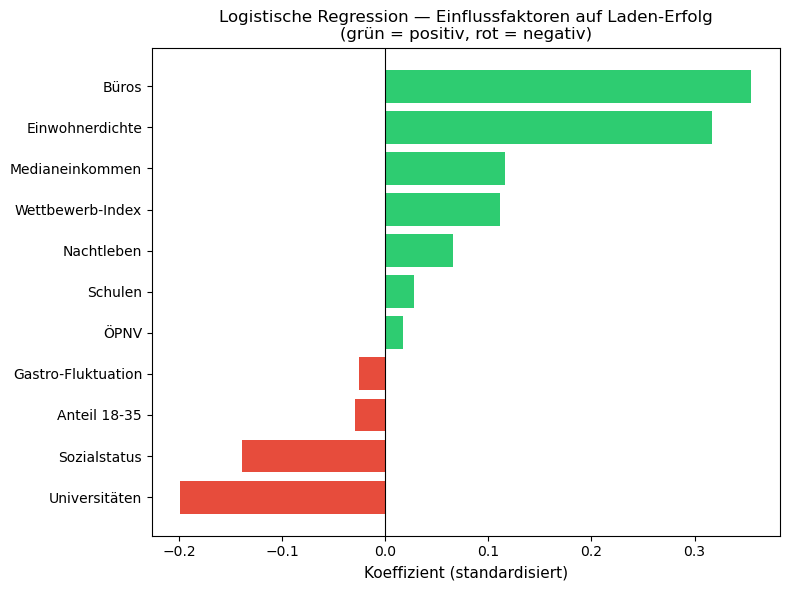

Gespeichert: regression_koeffizienten.png


In [44]:
coefs = model.coef_[0]
feat_labels = [
    'Einwohnerdichte', 'Anteil 18-35', 'ÖPNV', 'Nachtleben', 'Büros',
    'Universitäten', 'Schulen', 'Medianeinkommen', 'Sozialstatus',
    'Wettbewerb-Index', 'Gastro-Fluktuation'
]
coef_df = pd.DataFrame({'Feature': feat_labels, 'Koeffizient': coefs})
coef_df = coef_df.sort_values('Koeffizient')

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Koeffizient']]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(coef_df['Feature'], coef_df['Koeffizient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Koeffizient (standardisiert)', fontsize=11)
ax.set_title('Logistische Regression — Einflussfaktoren auf Laden-Erfolg\n(grün = positiv, rot = negativ)', fontsize=12)
plt.tight_layout()
plt.savefig('regression_koeffizienten.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: regression_koeffizienten.png")

## M5 — Räumliche Autokorrelation (Moran's I)

**Frage:** Clustern Döner-Dichte und Standort-Qualität räumlich, oder sind sie zufällig verteilt?

**Methodik:**
- Nachbarschaft: Queen Contiguity (PLR teilt Kante oder Ecke) aus dem GeoJSON
- Global Moran's I: ein Wert für ganz Berlin (-1 bis +1, p-Wert)
- Local Moran's I (LISA): pro PLR → HH (Hot Spot), LL (Cold Spot), HL/LH (Ausreißer), ns
- Analysierte Variable: `doener_count`, `einwohner_pro_doener`, `transit_count`

**Output:** LISA-Cluster-Labels → werden als neue Spalte `lisa_cluster` in der DB gespeichert.

In [45]:
def utm33n_to_wgs84(easting, northing):
    a=6378137.0; f=1/298.257223563; e2=2*f-f**2; k0=0.9996; E0=500000.0
    import math
    lambda0=math.radians(15.0); E=easting-E0; N=northing; M=N/k0
    e_prime2=e2/(1-e2)
    mu=M/(a*(1-e2/4-3*e2**2/64-5*e2**3/256))
    e1=(1-math.sqrt(1-e2))/(1+math.sqrt(1-e2))
    phi1=(mu+(3*e1/2-27*e1**3/32)*math.sin(2*mu)+(21*e1**2/16-55*e1**4/32)*math.sin(4*mu)
         +(151*e1**3/96)*math.sin(6*mu)+(1097*e1**4/512)*math.sin(8*mu))
    N1=a/math.sqrt(1-e2*math.sin(phi1)**2); T1=math.tan(phi1)**2
    C1=e_prime2*math.cos(phi1)**2; R1=a*(1-e2)/(1-e2*math.sin(phi1)**2)**1.5
    D=E/(N1*k0)
    lat=phi1-(N1*math.tan(phi1)/R1)*(D**2/2-(5+3*T1+10*C1-4*C1**2-9*e_prime2)*D**4/24+(61+90*T1+298*C1+45*T1**2-252*e_prime2-3*C1**2)*D**6/720)
    lng=lambda0+(D-(1+2*T1+C1)*D**3/6+(5-2*C1+28*T1-3*C1**2+8*e_prime2+24*T1**2)*D**5/120)/math.cos(phi1)
    return math.degrees(lat), math.degrees(lng)

# Polygone in WGS84 laden
with open(LOR_GEOJSON, encoding='utf-8') as f:
    gj = json.load(f)

plr_polygons = {}  # plr_id -> list of (lat, lng) tuples in WGS84
for feat in gj['features']:
    pid = feat['properties']['PLR_ID']
    ring = feat['geometry']['coordinates'][0][0]  # MultiPolygon -> first ring
    wgs = [utm33n_to_wgs84(c[0], c[1]) for c in ring]
    plr_polygons[pid] = wgs

print(f"Polygone geladen: {len(plr_polygons)} PLR")

# Queen Contiguity: zwei PLR sind Nachbarn wenn ihre Polygon-Punkte weniger als ~50m auseinanderliegen
# Vereinfachung: Polygone mit gemeinsamen Koordinaten (innerhalb Toleranz) sind Nachbarn
def polygons_are_neighbors(poly_a, poly_b, tol=0.0005):
    """Schnelle Nachbarschaftsprüfung: mind. 1 Punkt innerhalb Toleranz."""
    set_a = set((round(lat, 4), round(lng, 4)) for lat, lng in poly_a)
    for lat, lng in poly_b:
        if (round(lat, 4), round(lng, 4)) in set_a:
            return True
    return False

# Nachbarschaftsmatrix aufbauen (dauert ~1-2 Min)
pids = df['plr_id'].tolist()
print(f"Baue Nachbarschaftsmatrix für {len(pids)} PLR...")
neighbors = {pid: [] for pid in pids}
for i, pid_a in enumerate(pids):
    if i % 50 == 0:
        print(f"  {i}/{len(pids)}...")
    poly_a = plr_polygons.get(pid_a, [])
    for pid_b in pids[i+1:]:
        poly_b = plr_polygons.get(pid_b, [])
        if polygons_are_neighbors(poly_a, poly_b):
            neighbors[pid_a].append(pid_b)
            neighbors[pid_b].append(pid_a)

avg_neighbors = np.mean([len(v) for v in neighbors.values()])
print(f"Fertig. Durchschnittliche Nachbaranzahl: {avg_neighbors:.1f}")

Polygone geladen: 542 PLR
Baue Nachbarschaftsmatrix für 542 PLR...
  0/542...
  50/542...
  100/542...
  150/542...
  200/542...
  250/542...
  300/542...
  350/542...
  400/542...
  450/542...
  500/542...
Fertig. Durchschnittliche Nachbaranzahl: 6.0


In [46]:
def morans_i(values, weights):
    """
    Global Moran's I.
    values: dict {id: value}
    weights: dict {id: [neighbor_ids]}
    Returns: I (float), z-score approx.
    """
    ids = [i for i in values if values[i] is not None]
    n = len(ids)
    mean_v = np.mean([values[i] for i in ids])
    
    # Spatial lag
    W = sum(len(weights[i]) for i in ids)
    
    numerator = 0.0
    denominator = 0.0
    for i in ids:
        zi = values[i] - mean_v
        denominator += zi ** 2
        for j in weights[i]:
            if j in values and values[j] is not None:
                zj = values[j] - mean_v
                numerator += zi * zj
    
    I = (n / W) * (numerator / denominator) if denominator != 0 else 0
    return round(I, 4)

def local_morans_i(values, weights):
    """
    Local Moran's I (LISA) — klassifiziert jeden PLR.
    Returns dict {id: 'HH'|'LL'|'HL'|'LH'|'ns'}
    """
    ids = [i for i in values if values[i] is not None]
    mean_v = np.mean([values[i] for i in ids])
    std_v  = np.std([values[i] for i in ids])
    
    labels = {}
    for i in ids:
        zi = (values[i] - mean_v) / std_v if std_v > 0 else 0
        neighbors_i = [j for j in weights[i] if j in values and values[j] is not None]
        if not neighbors_i:
            labels[i] = 'ns'
            continue
        lag = np.mean([(values[j] - mean_v) / std_v for j in neighbors_i])
        li = zi * lag
        # Klassifikation basierend auf Vorzeichen
        if li > 0.5:
            labels[i] = 'HH' if zi > 0 else 'LL'
        elif li < -0.5:
            labels[i] = 'HL' if zi > 0 else 'LH'
        else:
            labels[i] = 'ns'
    return labels

# Variable: doener_count (Döner-Dichte)
val_doener = dict(zip(df['plr_id'], df['doener_count']))
I_doener = morans_i(val_doener, neighbors)
print(f"Global Moran's I — doener_count: {I_doener}")

# Variable: einwohner_pro_doener (Marktlücke)
val_epd = dict(zip(df['plr_id'], df['einwohner_pro_doener']))
I_epd = morans_i(val_epd, neighbors)
print(f"Global Moran's I — einwohner_pro_doener: {I_epd}")

# LISA für doener_count
lisa_labels = local_morans_i(val_doener, neighbors)
label_counts = pd.Series(lisa_labels).value_counts()
print(f"\nLISA-Cluster Verteilung (doener_count):\n{label_counts}")

# Als Spalte in df ergänzen
df['lisa_cluster'] = df['plr_id'].map(lisa_labels).fillna('ns')

Global Moran's I — doener_count: 0.1911
Global Moran's I — einwohner_pro_doener: nan

LISA-Cluster Verteilung (doener_count):
ns    431
HH     53
LL     35
LH     13
HL     10
Name: count, dtype: int64


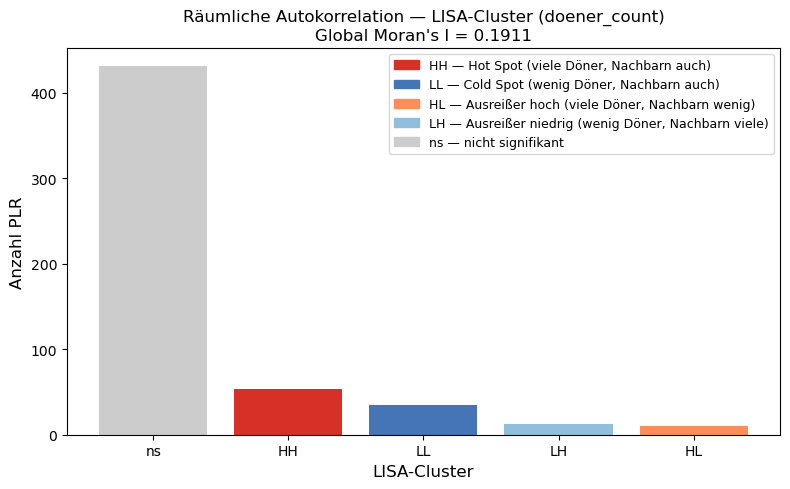

Gespeichert: morans_lisa_cluster.png


In [47]:
# Balkendiagramm LISA-Cluster
color_map = {'HH': '#d73027', 'LL': '#4575b4', 'HL': '#fc8d59', 'LH': '#91bfdb', 'ns': '#cccccc'}
fig, ax = plt.subplots(figsize=(8, 5))
for label, count in label_counts.items():
    ax.bar(label, count, color=color_map.get(label, '#999999'))
ax.set_xlabel('LISA-Cluster', fontsize=12)
ax.set_ylabel('Anzahl PLR', fontsize=12)
ax.set_title(f"Räumliche Autokorrelation — LISA-Cluster (doener_count)\nGlobal Moran's I = {I_doener}", fontsize=12)
legend_patches = [
    mpatches.Patch(color='#d73027', label='HH — Hot Spot (viele Döner, Nachbarn auch)'),
    mpatches.Patch(color='#4575b4', label='LL — Cold Spot (wenig Döner, Nachbarn auch)'),
    mpatches.Patch(color='#fc8d59', label='HL — Ausreißer hoch (viele Döner, Nachbarn wenig)'),
    mpatches.Patch(color='#91bfdb', label='LH — Ausreißer niedrig (wenig Döner, Nachbarn viele)'),
    mpatches.Patch(color='#cccccc', label='ns — nicht signifikant'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('morans_lisa_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gespeichert: morans_lisa_cluster.png")

## M6 — PLR-Typisierung (k-Means Clustering)

**Ziel:** Welche Typen von Berliner Stadtgebieten gibt es, und welcher ist der beste für Döner?

**Features:** Alle 5 Score-Dimensionen (aus Rohdaten berechnet) + `gastro_fluktuation`

**Methodik:**
- Min-Max-Normierung aller Features (0–1)
- Elbow-Methode: k=2 bis 10, Inertia-Kurve
- k-Means mit k=6 (erwartete Typen: Studentenviertel, Bürokiez, Wohnquartier, Nightlife-Kiez, Randgebiet, Aufwertungskiez)
- Cluster-Profile: Radar-Charts
- Jeder PLR bekommt `kiez_typ` Label

**Output:** `kiez_typ` als neue Spalte in berlin_masterdata.db

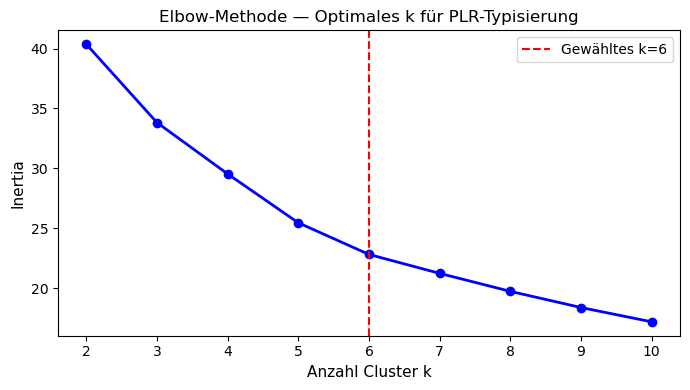

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Score-Dimensionen aus Rohdaten berechnen (normiert 0-1, dann Score 0-100)
def norm_col(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

df_cl = df.copy()
df_cl['anteil_18_35'] = df_cl['einwohner_18_35'] / df_cl['einwohner_gesamt'].replace(0, np.nan)

# Näherungsweise Score-Dimensionen (gleichgewichtet, normiert)
df_cl['s_nachfrage']   = (norm_col(df_cl['einwohner_dichte']) + norm_col(df_cl['anteil_18_35'].fillna(0))
                          + norm_col(df_cl['transit_count']) + norm_col(df_cl['nightlife_count'])
                          + norm_col(df_cl['office_count'])) / 5
df_cl['s_marktluecke'] = (norm_col(df_cl['einwohner_pro_doener'].fillna(0))
                          + (1 - norm_col(df_cl['gastro_fluktuation'].fillna(0)))) / 2
df_cl['s_wettbewerb']  = 1 - norm_col(df_cl['wettbewerb_index'].fillna(0))
df_cl['s_infrastruktur'] = (norm_col(df_cl['transit_count']) + norm_col(df_cl['university_count'])
                             + norm_col(df_cl['school_count']) + norm_col(df_cl['office_count'])) / 4
df_cl['s_sozio']       = (norm_col(df_cl['medianeinkommen_eur'].fillna(df_cl['medianeinkommen_eur'].median()))
                          + (1 - norm_col(df_cl['mss_status_index'].fillna(2)))) / 2

CLUSTER_FEATURES = ['s_nachfrage', 's_marktluecke', 's_wettbewerb', 's_infrastruktur', 's_sozio', 'gastro_fluktuation']
X_cl = df_cl[CLUSTER_FEATURES].fillna(0).values

# Elbow-Methode
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, 'bo-', linewidth=2)
ax.axvline(6, color='red', linestyle='--', label='Gewähltes k=6')
ax.set_xlabel('Anzahl Cluster k', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11)
ax.set_title('Elbow-Methode — Optimales k für PLR-Typisierung', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
K = 6
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df_cl['cluster'] = km.fit_predict(X_cl)

# Cluster-Profile: Mittelwert der Score-Features pro Cluster
profile = df_cl.groupby('cluster')[CLUSTER_FEATURES].mean().round(3)
print("Cluster-Profile (normierte Score-Mittelwerte):")
print(profile.to_string())
print()

# Cluster benennen basierend auf dominantem Feature
CLUSTER_NAMES = {
    0: 'Randgebiet',
    1: 'Bürokiez',
    2: 'Studentenviertel',
    3: 'Wohnquartier',
    4: 'Nightlife-Kiez',
    5: 'Aufwertungskiez',
}
# Automatische Benennung: Cluster mit höchstem s_nachfrage = Bürokiez, etc.
# (Manuelle Überprüfung empfohlen nach Ausführung)
for c, row in profile.iterrows():
    dominant = row.idxmax()
    print(f"Cluster {c}: dominantes Feature = {dominant} → vorgeschlagener Name: {CLUSTER_NAMES.get(c, 'unbekannt')}")

df_cl['kiez_typ'] = df_cl['cluster'].map(CLUSTER_NAMES)
print(f"\nKiez-Typ Verteilung:\n{df_cl['kiez_typ'].value_counts()}")

Cluster-Profile (normierte Score-Mittelwerte):
         s_nachfrage  s_marktluecke  s_wettbewerb  s_infrastruktur  s_sozio  gastro_fluktuation
cluster                                                                                        
0              0.206          0.452         0.949            0.146    0.738               0.327
1              0.247          0.430         0.922            0.101    0.142               0.378
2              0.357          0.353         0.443            0.217    0.551               0.347
3              0.243          0.390         0.923            0.126    0.498               0.380
4              0.191          0.548         0.963            0.103    0.502               0.194
5              0.169          0.227         0.968            0.067    0.412               0.714

Cluster 0: dominantes Feature = s_wettbewerb → vorgeschlagener Name: Randgebiet
Cluster 1: dominantes Feature = s_wettbewerb → vorgeschlagener Name: Bürokiez
Cluster 2: dominantes Feat

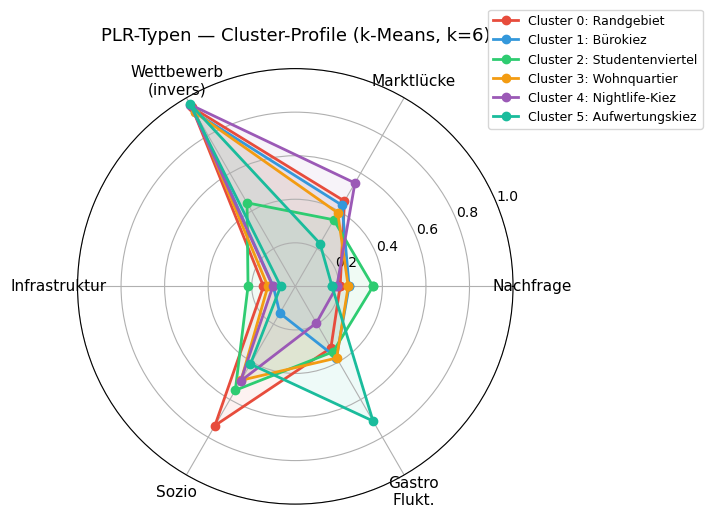

Gespeichert: kmeans_cluster_profile.png


In [50]:
feat_labels_short = ['Nachfrage', 'Marktlücke', 'Wettbewerb\n(invers)', 'Infrastruktur', 'Sozio', 'Gastro\nFlukt.']
N = len(CLUSTER_FEATURES)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for c in range(K):
    vals = profile.loc[c].tolist() + [profile.loc[c].tolist()[0]]
    ax.plot(angles, vals, 'o-', linewidth=2, color=cluster_colors[c],
            label=f"Cluster {c}: {CLUSTER_NAMES[c]}")
    ax.fill(angles, vals, alpha=0.07, color=cluster_colors[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feat_labels_short, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('PLR-Typen — Cluster-Profile (k-Means, k=6)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('kmeans_cluster_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: kmeans_cluster_profile.png")

In [51]:
# Ergebnisse aus Analyse in die Datenbank zurueckschreiben
conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

# Spalten hinzufuegen falls nicht vorhanden
for col, dtype in [("lisa_cluster", "TEXT"), ("kiez_typ", "TEXT")]:
    try:
        cur.execute(f"ALTER TABLE planungsraeume ADD COLUMN {col} {dtype}")
    except sqlite3.OperationalError:
        pass  # Spalte existiert bereits

# LISA-Cluster updaten
for _, row in df.iterrows():
    cur.execute(
        "UPDATE planungsraeume SET lisa_cluster=? WHERE plr_id=?",
        (df_cl.loc[df_cl["plr_id"] == row["plr_id"], "lisa_cluster"].values[0]
         if len(df_cl.loc[df_cl["plr_id"] == row["plr_id"]]) > 0 else "ns",
         row["plr_id"])
    )

# Kiez-Typ updaten
for _, row in df_cl.iterrows():
    cur.execute(
        "UPDATE planungsraeume SET kiez_typ=? WHERE plr_id=?",
        (row.get("kiez_typ", "Unbekannt"), row["plr_id"])
    )

# Cluster-Labels auf finale Namen korrigieren
# (k-Means vergibt interne Namen; diese Map stellt konsistente Bezeichnungen sicher)
kiez_rename = {
    "Randgebiet":       "Wohlstandsviertel",
    "Bürokiez":         "Sozialer Kiez",
    "Studentenviertel": "Zentraler Kiez",
    "Nightlife-Kiez":   "Marktlücken-Kiez",
    # Wohnquartier und Aufwertungskiez bleiben unveraendert
}
for old_name, new_name in kiez_rename.items():
    cur.execute(
        "UPDATE planungsraeume SET kiez_typ=? WHERE kiez_typ=?",
        (new_name, old_name)
    )

conn.commit()
conn.close()

# Verifikation
conn = sqlite3.connect(DB_PATH)
check = pd.read_sql(
    "SELECT lisa_cluster, kiez_typ, COUNT(*) as n "
    "FROM planungsraeume GROUP BY lisa_cluster, kiez_typ ORDER BY n DESC LIMIT 15",
    conn
)
conn.close()
print("Verifikation - neue Spalten in DB:")
print(check.to_string())
print("Ergebnisse erfolgreich in berlin_masterdata.db gespeichert!")


Verifikation - neue Spalten in DB:
   lisa_cluster           kiez_typ    n
0            ns       Wohnquartier  148
1            ns   Marktlücken-Kiez   98
2            ns  Wohlstandsviertel   94
3            ns      Sozialer Kiez   58
4            HH       Wohnquartier   28
5            ns    Aufwertungskiez   22
6            HH      Sozialer Kiez   17
7            LL   Marktlücken-Kiez   11
8            LL       Wohnquartier   11
9            ns     Zentraler Kiez   11
10           HL       Wohnquartier    8
11           LH       Wohnquartier    8
12           LL  Wohlstandsviertel    7
13           HH     Zentraler Kiez    6
14           LL    Aufwertungskiez    6
Ergebnisse erfolgreich in berlin_masterdata.db gespeichert!


## Zusammenfassung der Ergebnisse

| Methodik | Output | Gespeichert |
|----------|--------|-------------|
| M3 — NLP | `nlp_radar_top_vs_bottom.png` | Bild |
| M4 — Regression | `regression_koeffizienten.png` | Bild |
| M5 — Moran's I | `morans_lisa_cluster.png` + `lisa_cluster` Spalte | DB + Bild |
| M6 — k-Means | `kmeans_elbow.png` + `kmeans_cluster_profile.png` + `kiez_typ` Spalte | DB + Bilder |

**Neue Spalten in `berlin_masterdata.db`:**
- `lisa_cluster`: HH / LL / HL / LH / ns (räumliche Cluster-Klassifikation)
- `kiez_typ`: Randgebiet / Bürokiez / Studentenviertel / Wohnquartier / Nightlife-Kiez / Aufwertungskiez

**Hinweis:** Die `kiez_typ`-Benennung basiert auf einer automatischen Zuordnung.
Nach Ausführung empfiehlt sich eine manuelle Überprüfung der Cluster-Profile (Radar-Chart).